In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [13]:
# Set the actual dataset path
dataset_path = r"Vegetable Images/Test/"

# Check that path exists
print("Dataset exists:", os.path.exists(dataset_path))

# Show class folders
class_names = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Classes found:", class_names)
print("Number of classes:", len(class_names))

Dataset exists: True
Classes found: ['.ipynb_checkpoints', 'Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Broccoli', 'Carrot', 'Cauliflower', 'Cucumber', 'Tomato']
Number of classes: 9


{'.ipynb_checkpoints': 0, 'Bean': 5, 'Bitter_Gourd': 5, 'Bottle_Gourd': 5, 'Broccoli': 5, 'Carrot': 5, 'Cauliflower': 5, 'Cucumber': 5, 'Tomato': 5}


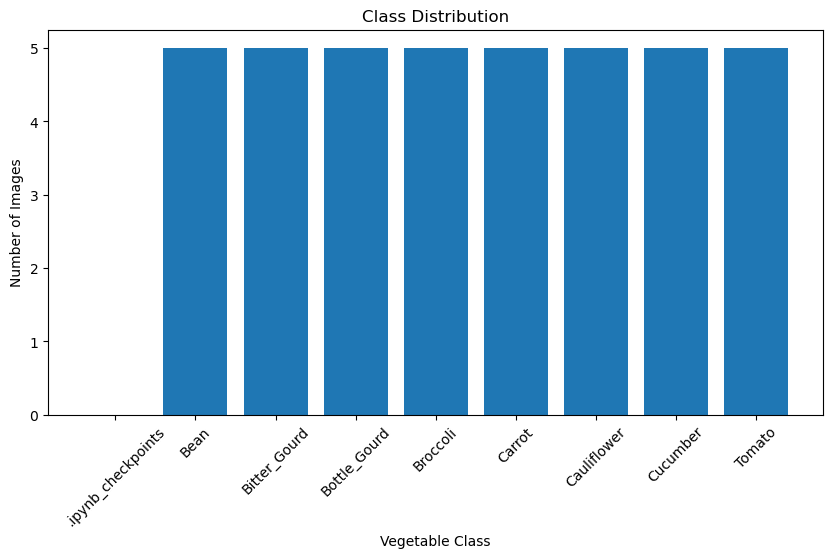

In [15]:
# Count images in each class
class_counts = {}
for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    count = len([
        f for f in os.listdir(class_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    class_counts[class_name] = count

print(class_counts)

# Plot class distribution
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Vegetable Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [17]:
class_names = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
    and folder != ".ipynb_checkpoints"
])

{'Bean': 5, 'Bitter_Gourd': 5, 'Bottle_Gourd': 5, 'Broccoli': 5, 'Carrot': 5, 'Cauliflower': 5, 'Cucumber': 5, 'Tomato': 5}


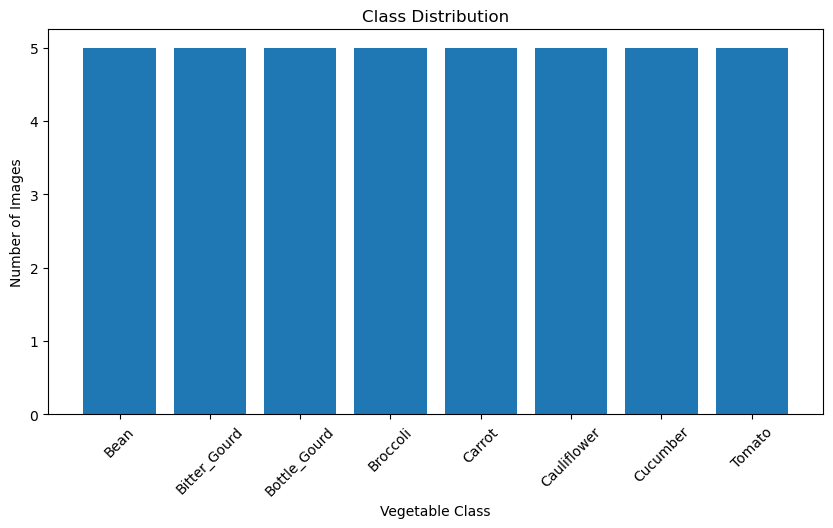

In [19]:
class_counts = {}
for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    count = len([
        f for f in os.listdir(class_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    class_counts[class_name] = count

print(class_counts)

# Plot class distribution
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Vegetable Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [21]:
# Image settings
img_height = 128
img_width = 128
batch_size = 8

# Load dataset and split into training + validation
train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Save class names
class_names = train_ds.class_names
print("Class names:", class_names)
print("Number of classes:", len(class_names))

Found 43 files belonging to 8 classes.
Using 35 files for training.
Found 43 files belonging to 8 classes.
Using 8 files for validation.
Class names: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Broccoli', 'Carrot', 'Cauliflower', 'Cucumber', 'Tomato']
Number of classes: 8


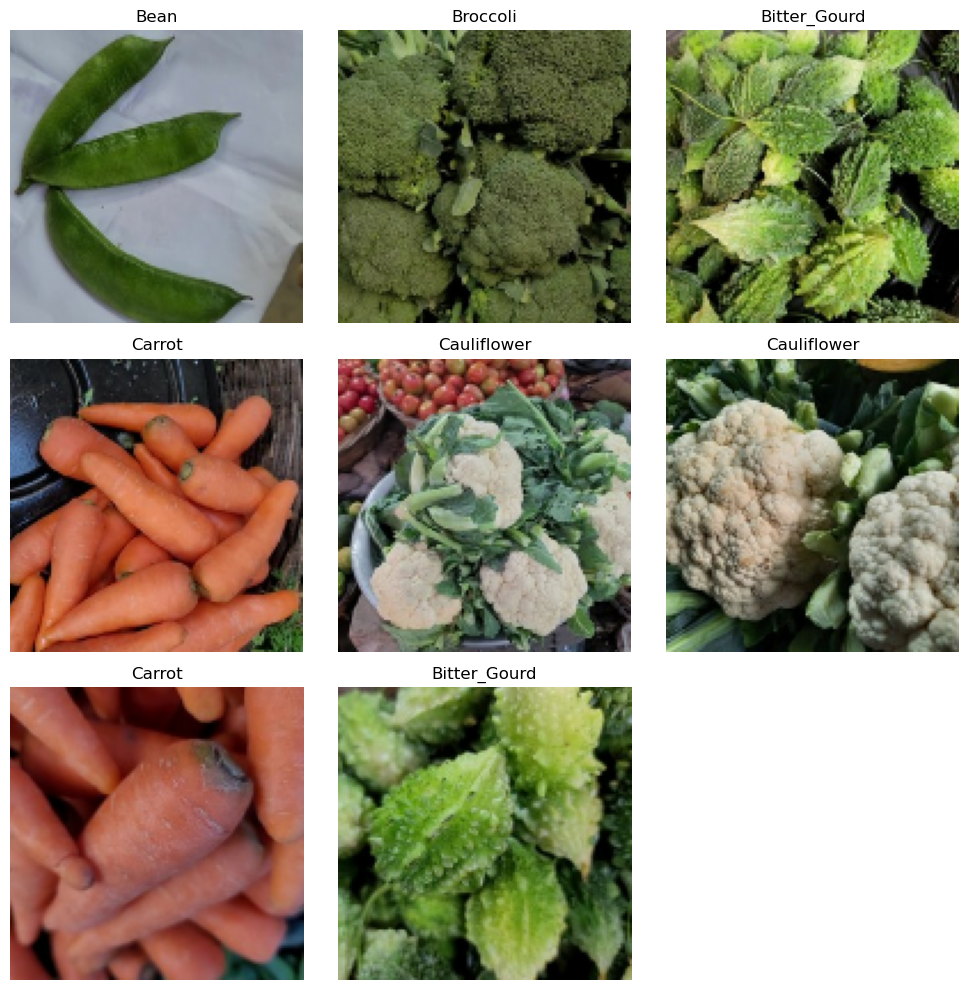

In [23]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

C:\Users\rab12\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,672 (12.61 MB)

 Trainable params: 3,305,672 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.0857 - loss: 2.5674 - val_accuracy: 0.2500 - val_loss: 2.0436
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3429 - loss: 2.0346 - val_accuracy: 0.1250 - val_loss: 2.0274
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2857 - loss: 1.8936 - val_accuracy: 0.1250 - val_loss: 1.9571
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2571 - loss: 1.7710 - val_accuracy: 0.1250 - val_loss: 2.0804
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3143 - loss: 1.6340 - val_accuracy: 0.2500 - val_loss: 1.8266
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4857 - loss: 1.4943 - val_accuracy: 0.2500 - val_loss: 1.8640
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6857 - loss: 1.0416 - val_accuracy: 0.3750 - val_loss: 2.5694
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8000 - loss: 0.7583 - val_accuracy: 0.3750 - val_loss: 1.7309


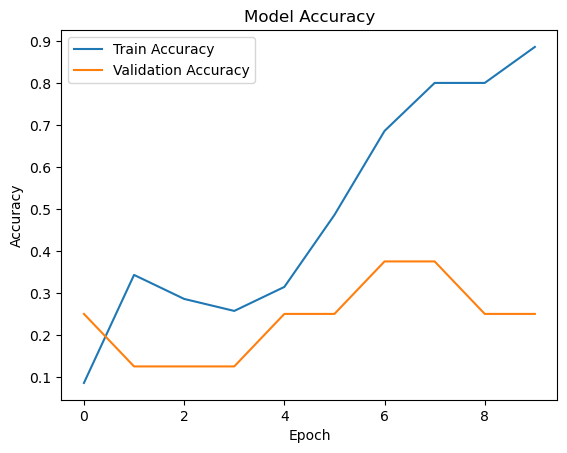

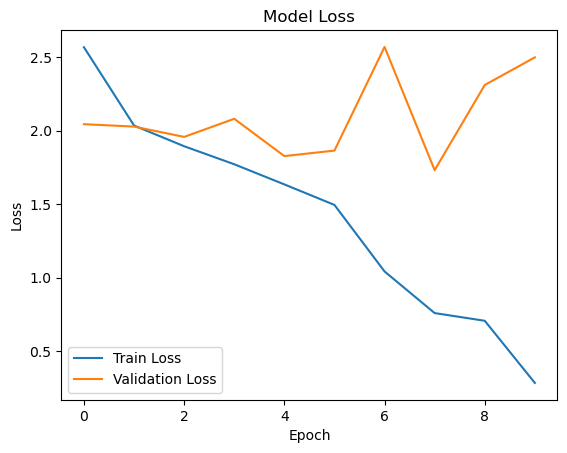

In [31]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [33]:
# Get predictions
y_pred = model.predict(val_ds)

# Convert probabilities → class index
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[[0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 1]
 [0 0 0 0 1 0 0 0]]


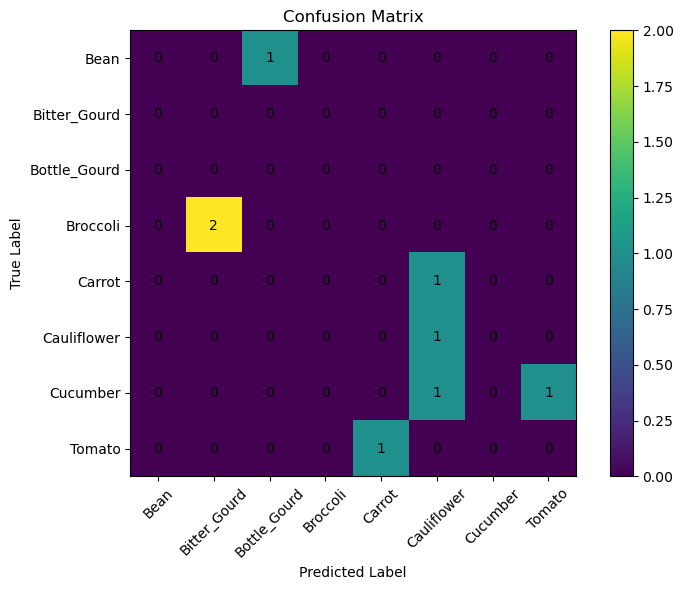

In [35]:
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

In [39]:
# The dataset used for this was a vegetable image set, which inlcuded various types of vegetables such as beans, carrots, cucumbers,
# tomatos and more. Each class only had 5 images of each in them so the data set was small. It was originally much larger but because
# of computer limitations I had to manually shrink the dataset. This caused the validation accuracy to not do so well. The target was
# for the model to predict the vegetable based on the image. Images were organized by class folders and loaded by TensorFlow, which 
# then were resized to all the same and adjusted pixel value. Using multiple Convolutional layers allowed the model to learn the 
# features of the images and pooling let it really focus on the important features of each class. The training accuracy did quite well
# reaching 88% accuracy but the validation accuracy was not so good only staying at 25%. The main cause of this was probably because
# of how small I actually ended up making the data set, and it not having enough images to really learn enough to confidently identify
# new images of the vegetable classes. Overall the CNN model did a good job at accurately training and learning from the provided 
# images but lacked in general growth. A good way to improve that though would to be increasing the size of the data set or using dropout. 

In [41]:
model_dropout = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    
    layers.Dropout(0.5),
    
    layers.Dense(len(class_names), activation='softmax')
])

model_dropout.summary()

C:\Users\rab12\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,672 (12.61 MB)

 Trainable params: 3,305,672 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
history_dropout = model_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.0857 - loss: 2.3890 - val_accuracy: 0.0000e+00 - val_loss: 2.1347
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1429 - loss: 2.0557 - val_accuracy: 0.0000e+00 - val_loss: 2.1462
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1714 - loss: 1.9972 - val_accuracy: 0.0000e+00 - val_loss: 2.2979
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1429 - loss: 2.0658 - val_accuracy: 0.2500 - val_loss: 2.1559
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3429 - loss: 1.8358 - val_accuracy: 0.2500 - val_loss: 2.1650
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4286 - loss: 1.7673 - val_accuracy: 0.2500 - val_loss: 1.9648
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5429 - loss: 1.3488 - val_accuracy: 0.2500 - val_loss: 2.1689
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5429 - loss: 1.1587 - val_accuracy: 0.3750 - val_l

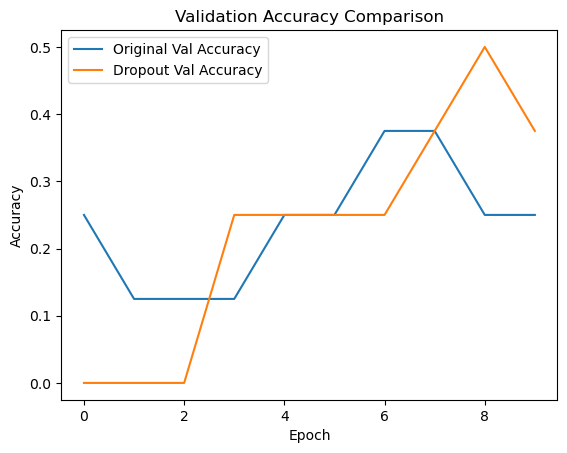

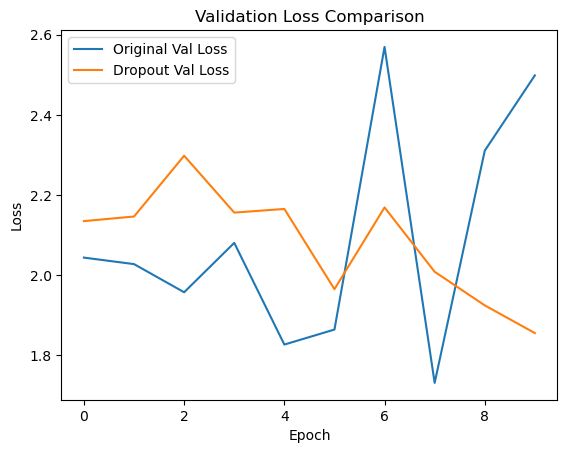

In [47]:
import matplotlib.pyplot as plt

# Accuracy comparison
plt.plot(history.history['val_accuracy'], label='Original Val Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout Val Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss comparison
plt.plot(history.history['val_loss'], label='Original Val Loss')
plt.plot(history_dropout.history['val_loss'], label='Dropout Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()